# C-MAPSS Modeling — `modeling_v4_dann` · Domain-Adversarial Neural Network (FD001 -> FD002)

**Course project:** 24-788 Introduction to Deep Learning (Spring 2026), 2-person team  
**This notebook:** Contribution 2 — Domain-Adversarial Neural Network (DANN) for unsupervised domain adaptation from FD001 to FD002.

**The problem.** FD001 has 1 operating condition; FD002 has 6. A model trained on labeled FD001 data fails on FD002 because sensor readings at the same degradation level look different across regimes. The FD001->FD002 gap is the motivating use case from the EDA: PCA shows FD002 splitting into 6 distinct regime clouds that an FD001-trained model has never seen.

**The approach.** DANN (Ganin et al., 2016) learns regime-invariant features by adding a domain classifier head to the shared LSTM encoder and training it adversarially via a Gradient Reversal Layer (GRL). The encoder is pushed to produce representations that (a) predict RUL accurately on labeled FD001 windows, and (b) are indistinguishable between FD001 and FD002 windows. Only FD001 RUL labels are consumed; FD002 contributes unlabeled windows only.

**Three-way evaluation on FD002 test set:**
- Lower bound: v2 LSTM (FD001-trained) evaluated naively on FD002 -- no adaptation.
- DANN: this notebook -- domain-adversarial adaptation with unlabeled FD002 train windows.
- Upper bound: LSTM trained directly on labeled FD002 -- what full supervision would give.

**Hardware target:** Apple Silicon (MPS), with CUDA / CPU fallback.  
**Time budget:** ~20-25 minutes on an M4 MacBook Pro (three training runs).

**Reference:** Ganin et al. (2016), "Domain-Adversarial Training of Neural Networks", JMLR.  
https://jmlr.org/papers/v17/15-239.html


## 1 · Setup

Identical to `modeling_v2`. Place `CMAPSSData/` next to this notebook before running.


In [1]:
import os, time, random, math, json
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F
from torch import nn, optim
from torch.autograd import Function
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from IPython.display import display, clear_output

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device pattern: cuda -> mps -> cpu
if torch.cuda.is_available():
    Device = "cuda"
elif torch.backends.mps.is_available():
    Device = "mps"
else:
    Device = "cpu"
print(f"Device : {Device}")
print(f"PyTorch: {torch.__version__}")

sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = Path("CMAPSSData")
CKPT_DIR = Path("checkpoints"); CKPT_DIR.mkdir(exist_ok=True)
FIG_DIR  = Path("figures");     FIG_DIR.mkdir(exist_ok=True)

assert DATA_DIR.exists(), "Place CMAPSSData/ next to this notebook (or edit DATA_DIR)."

Device : mps
PyTorch: 2.11.0


## 2 · Shared data constants

Sensor set, window length, and RUL clip are locked to the same values as `modeling_v2` so results are directly comparable.

One important difference from v2: normalization statistics are computed on **FD001 train only** and applied to both FD001 and FD002. This is the correct unsupervised adaptation setup -- we assume no access to FD002 labels or statistics at training time.


In [2]:
COLS = (["unit", "cycle", "setting_1", "setting_2", "setting_3"]
        + [f"s_{i}" for i in range(1, 22)])
SENSORS_ALL = [c for c in COLS if c.startswith("s_")]

# Same sensor drop as v2 (from eda_v1)
DROP_SENSORS = ["s_1", "s_5", "s_6", "s_10", "s_16", "s_18", "s_19"]
USE_SENSORS  = [s for s in SENSORS_ALL if s not in DROP_SENSORS]
print(f"Using {len(USE_SENSORS)} sensors: {USE_SENSORS}")

W        = 30   # sliding window length
RUL_CLIP = 130  # same as v2

def load_subset(subset: str):
    train = pd.read_csv(DATA_DIR / f"train_{subset}.txt", sep=r"\s+",
                        header=None, names=COLS, engine="python")
    test  = pd.read_csv(DATA_DIR / f"test_{subset}.txt",  sep=r"\s+",
                        header=None, names=COLS, engine="python")
    rul   = pd.read_csv(DATA_DIR / f"RUL_{subset}.txt",   sep=r"\s+",
                        header=None, names=["RUL"], engine="python")["RUL"].values
    return train, test, rul

# Load both subsets
fd1_train, fd1_test, fd1_true_rul = load_subset("FD001")
fd2_train, fd2_test, fd2_true_rul = load_subset("FD002")

print(f"FD001: train rows={len(fd1_train):,}, test engines={fd1_test['unit'].nunique()}")
print(f"FD002: train rows={len(fd2_train):,}, test engines={fd2_test['unit'].nunique()}")

Using 14 sensors: ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
FD001: train rows=20,631, test engines=100
FD002: train rows=53,759, test engines=259


In [3]:
def add_rul(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    max_cycle = df.groupby("unit")["cycle"].transform("max")
    df["RUL"] = max_cycle - df["cycle"]
    return df

fd1_train = add_rul(fd1_train)
fd2_train = add_rul(fd2_train)

# Normalization stats from FD001 train ONLY -- no FD002 statistics consumed.
# This is the unsupervised adaptation assumption: we know nothing about the target
# domain's scale at training time.
train_means = fd1_train[USE_SENSORS].mean()
train_stds  = fd1_train[USE_SENSORS].std().replace(0, 1.0)

def normalize(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df[USE_SENSORS] = (df[USE_SENSORS] - train_means) / train_stds
    return df

fd1_train = normalize(fd1_train)
fd1_test  = normalize(fd1_test)
fd2_train = normalize(fd2_train)
fd2_test  = normalize(fd2_test)

print("FD001 train RUL (un-clipped): "
      f"mean={fd1_train['RUL'].mean():.1f}, max={fd1_train['RUL'].max()}")
print("FD002 train RUL (un-clipped): "
      f"mean={fd2_train['RUL'].mean():.1f}, max={fd2_train['RUL'].max()}")

FD001 train RUL (un-clipped): mean=107.8, max=361
FD002 train RUL (un-clipped): mean=108.2, max=377


## 3 · Datasets

Three datasets are needed:

- `src_train_set` / `src_val_set`: FD001 labeled windows (source domain). 80/20 engine split, same as v2.
- `tgt_train_set`: FD002 **unlabeled** windows (target domain). RUL labels are generated but never passed to the RUL loss -- only used by the domain classifier head to signal "this is target domain."
- Test windows for FD001 and FD002 (one window per engine, last W cycles).

The `CMAPSSWindowDataset` class is copied verbatim from v2.


In [4]:
class CMAPSSWindowDataset(Dataset):
    """Sliding-window dataset. One sample per (engine, end_cycle) pair."""
    def __init__(self, df: pd.DataFrame, sensors, window: int, rul_clip: int):
        self.X = []
        self.y = []
        for _, eng in df.groupby("unit"):
            sensor_array = eng[sensors].values.astype(np.float32)
            rul_array    = np.minimum(eng["RUL"].values.astype(np.float32), rul_clip)
            L = len(eng)
            if L < window:
                continue
            for end in range(window, L + 1):
                self.X.append(sensor_array[end - window : end])
                self.y.append(rul_array[end - 1])
        self.X = np.stack(self.X)
        self.y = np.array(self.y, dtype=np.float32)

    def __len__(self):  return len(self.X)
    def __getitem__(self, i):
        return torch.from_numpy(self.X[i]), torch.tensor(self.y[i])


def build_test_windows(df: pd.DataFrame, sensors, window: int) -> np.ndarray:
    """One window per test engine: last `window` cycles, front-padded if needed."""
    Xs = []
    for _, eng in df.groupby("unit"):
        arr = eng[sensors].values.astype(np.float32)
        if len(arr) >= window:
            Xs.append(arr[-window:])
        else:
            pad = np.tile(arr[0:1], (window - len(arr), 1))
            Xs.append(np.concatenate([pad, arr], axis=0))
    return np.stack(Xs)


# FD001 source: 80/20 engine-level split
rng       = np.random.default_rng(SEED)
src_units = fd1_train["unit"].unique()
val_units = rng.choice(src_units, size=int(0.2 * len(src_units)), replace=False)
val_mask  = fd1_train["unit"].isin(val_units)

src_train_set = CMAPSSWindowDataset(fd1_train[~val_mask], USE_SENSORS, W, RUL_CLIP)
src_val_set   = CMAPSSWindowDataset(fd1_train[ val_mask], USE_SENSORS, W, RUL_CLIP)

# FD002 target: all train windows (unlabeled -- labels generated but not used for RUL loss)
tgt_train_set = CMAPSSWindowDataset(fd2_train, USE_SENSORS, W, RUL_CLIP)

# Test windows
X_test_fd1 = build_test_windows(fd1_test, USE_SENSORS, W)
X_test_fd2 = build_test_windows(fd2_test, USE_SENSORS, W)
y_test_fd1 = fd1_true_rul.astype(np.float32)
y_test_fd2 = fd2_true_rul.astype(np.float32)

print(f"Source train windows : {len(src_train_set):,}  (FD001, {len(src_units)-len(val_units)} engines)")
print(f"Source val   windows : {len(src_val_set):,}  (FD001, {len(val_units)} engines)")
print(f"Target train windows : {len(tgt_train_set):,}  (FD002, {fd2_train['unit'].nunique()} engines, unlabeled)")
print(f"FD001 test  windows  : {X_test_fd1.shape[0]}")
print(f"FD002 test  windows  : {X_test_fd2.shape[0]}")

Source train windows : 14,070  (FD001, 80 engines)
Source val   windows : 3,661  (FD001, 20 engines)
Target train windows : 46,219  (FD002, 260 engines, unlabeled)
FD001 test  windows  : 100
FD002 test  windows  : 259


## 4 · Gradient Reversal Layer

The GRL is the single novel piece of code in this notebook. It is a pass-through in the forward pass and negates (and scales) the gradient in the backward pass. This makes the encoder adversarial with respect to the domain classifier: the classifier tries to distinguish source from target, and the encoder tries to produce features that make that classification impossible.

The lambda parameter controls the strength of the reversal. We use the Ganin et al. ramp schedule:

    lambda(p) = 2 / (1 + exp(-10 * p)) - 1

where p goes from 0 to 1 over training. This starts the adversarial signal at near-zero (letting the RUL task converge first) and ramps it up as training progresses.


In [5]:
class GradientReversalFunction(Function):
    """Forward: identity. Backward: negate and scale gradient by lambda."""

    @staticmethod
    def forward(ctx, x: torch.Tensor, lam: float) -> torch.Tensor:
        ctx.save_for_backward(torch.tensor(lam))
        return x.clone()

    @staticmethod
    def backward(ctx, grad_output: torch.Tensor):
        lam, = ctx.saved_tensors
        return -lam.item() * grad_output, None  # None for lam's gradient (not a tensor param)


class GradientReversalLayer(nn.Module):
    """Wraps GradientReversalFunction as a module. `lam` is set externally each epoch."""
    def __init__(self):
        super().__init__()
        self.lam = 0.0

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return GradientReversalFunction.apply(x, self.lam)


def ganin_lambda(epoch: int, n_epochs: int, high: float = 1.0) -> float:
    """Ganin et al. (2016) lambda ramp: 0 -> high over n_epochs."""
    p = epoch / n_epochs
    return high * (2.0 / (1.0 + math.exp(-10.0 * p)) - 1.0)


# Sanity check: lambda should go from ~0 at epoch 0 to ~1 at epoch N
_n = 40
print("Lambda ramp (sample epochs):")
for ep in [0, 5, 10, 20, 30, 40]:
    print(f"  epoch {ep:2d}/{_n}: lambda = {ganin_lambda(ep, _n):.4f}")

Lambda ramp (sample epochs):
  epoch  0/40: lambda = 0.0000
  epoch  5/40: lambda = 0.5546
  epoch 10/40: lambda = 0.8483
  epoch 20/40: lambda = 0.9866
  epoch 30/40: lambda = 0.9989
  epoch 40/40: lambda = 0.9999


## 5 · DANN model

Three components sharing one encoder:

**Encoder** (`LSTMEncoder`): the 2-layer LSTM body from v2, hidden=64. Takes a window (B, W, F) and returns the last hidden state (B, H). The architecture is identical to v2's `LSTMRegressor.lstm` -- this lets us initialize from the v2 checkpoint if desired.

**RUL head** (`RULHead`): same FC head as v2, `Linear(64, 32) -> ReLU -> Linear(32, 1)`. Trained with MSE on labeled FD001 windows only.

**Domain classifier head** (`DomainHead`): `Linear(64, 32) -> ReLU -> Linear(32, 1)` with sigmoid output. Trained with BCE loss to distinguish source (label=0) from target (label=1). The GRL sits between the encoder output and this head, so the encoder is trained to fool the classifier.

The full `DANNModel` wraps all three and routes inputs through the correct path.


In [6]:
class LSTMEncoder(nn.Module):
    """Shared LSTM encoder. Returns last hidden state (B, hidden)."""
    def __init__(self, n_features: int, hidden: int = 64, num_layers: int = 2,
                 dropout: float = 0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features, hidden_size=hidden,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:  # x: (B, W, F)
        out, _ = self.lstm(x)                             # (B, W, H)
        return out[:, -1, :]                              # (B, H)


class RULHead(nn.Module):
    """Regression head: hidden -> scalar RUL prediction."""
    def __init__(self, hidden: int = 64, dropout: float = 0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, h: torch.Tensor) -> torch.Tensor:  # h: (B, H)
        return self.net(h).squeeze(-1)                   # (B,)


class DomainHead(nn.Module):
    """Binary domain classifier: hidden -> P(target domain). Sits after GRL."""
    def __init__(self, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, h: torch.Tensor) -> torch.Tensor:  # h: (B, H) after GRL
        return self.net(h).squeeze(-1)                   # (B,) raw logits


class DANNModel(nn.Module):
    """
    Full DANN model with shared encoder, RUL head, domain head, and GRL.

    Usage:
      rul_pred          = model.predict_rul(x)
      domain_logit      = model.predict_domain(x)   # after GRL
      rul_pred, d_logit = model(x_src, x_tgt)       # full forward during training
    """
    def __init__(self, n_features: int, hidden: int = 64, num_layers: int = 2,
                 dropout: float = 0.3):
        super().__init__()
        self.encoder = LSTMEncoder(n_features, hidden, num_layers, dropout)
        self.rul_head    = RULHead(hidden, dropout)
        self.domain_head = DomainHead(hidden)
        self.grl         = GradientReversalLayer()

    def predict_rul(self, x: torch.Tensor) -> torch.Tensor:
        """Inference-time RUL prediction (no GRL, no domain head)."""
        return self.rul_head(self.encoder(x))

    def forward(self, x_src: torch.Tensor,
                x_tgt: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Training forward pass.
        Returns:
          rul_pred   : (B_src,)   -- RUL predictions for source windows
          dom_logits : (B_src + B_tgt,) -- domain logits for concatenated batch
        """
        h_src = self.encoder(x_src)                         # (B_src, H)
        h_tgt = self.encoder(x_tgt)                         # (B_tgt, H)

        rul_pred = self.rul_head(h_src)                     # (B_src,)

        h_all       = torch.cat([h_src, h_tgt], dim=0)     # (B_src+B_tgt, H)
        h_reversed  = self.grl(h_all)                      # GRL applied
        dom_logits  = self.domain_head(h_reversed)          # (B_src+B_tgt,)

        return rul_pred, dom_logits


# Sanity check shapes
_n_feat = len(USE_SENSORS)
_model  = DANNModel(_n_feat).to(Device)
_xs = torch.randn(8, W, _n_feat, device=Device)
_xt = torch.randn(6, W, _n_feat, device=Device)
_rul, _dom = _model(_xs, _xt)
print(f"RUL pred shape   : {tuple(_rul.shape)}  (expected (8,))")
print(f"Domain pred shape: {tuple(_dom.shape)}  (expected (14,))")
print(f"Total params     : {sum(p.numel() for p in _model.parameters()):,}")
del _model, _xs, _xt, _rul, _dom

RUL pred shape   : (8,)  (expected (8,))
Domain pred shape: (14,)  (expected (14,))
Total params     : 57,986


## 6 · DANN-specific TrainTracker

Extended from v2's `TrainTracker` to track four loss components in a 2x2 subplot layout:
- Top-left: total loss = L_rul + lambda * L_domain
- Top-right: val RMSE on FD001 (source domain)
- Bottom-left: RUL loss (MSE on source windows)
- Bottom-right: domain loss (BCE on source + target) and current lambda


In [7]:
class DANNTracker:
    """Live 2x2 training plot for DANN: total loss, val RMSE, RUL loss, domain loss."""

    def __init__(self, n_epochs: int, plot_freq: int = 1):
        self.n_epochs    = n_epochs
        self.plot_freq   = plot_freq
        self.epoch       = 0
        self.total_loss  = []
        self.rul_loss    = []
        self.dom_loss    = []
        self.val_rmse    = []
        self.lam_hist    = []
        self._stopped_at = None
        self.t0          = time.time()
        self._init_fig()

    def _init_fig(self):
        plt.ioff()
        self.fig, axes = plt.subplots(2, 2, figsize=(13, 7))
        (self.ax_total, self.ax_val), (self.ax_rul, self.ax_dom) = axes

        self.c_total, = self.ax_total.plot([], [], color="steelblue")
        self.ax_total.set_title("Total loss  (RUL + lambda*domain)")
        self.ax_total.set_xlabel("Epoch"); self.ax_total.set_ylabel("Loss")
        self.ax_total.set_xlim(0, self.n_epochs + 1)
        self.ax_total.grid(linestyle="--", alpha=0.6)

        self.c_val,  = self.ax_val.plot([], [], color="darkorange")
        self.ax_val.set_title("Val RMSE  (FD001 source)")
        self.ax_val.set_xlabel("Epoch"); self.ax_val.set_ylabel("RMSE (cycles)")
        self.ax_val.set_xlim(0, self.n_epochs + 1)
        self.ax_val.grid(linestyle="--", alpha=0.6)

        self.c_rul,  = self.ax_rul.plot([], [], color="seagreen")
        self.ax_rul.set_title("RUL loss  (MSE on source)")
        self.ax_rul.set_xlabel("Epoch"); self.ax_rul.set_ylabel("MSE loss")
        self.ax_rul.set_xlim(0, self.n_epochs + 1)
        self.ax_rul.grid(linestyle="--", alpha=0.6)

        self.c_dom,  = self.ax_dom.plot([], [], color="mediumpurple", label="domain BCE")
        self.c_lam,  = self.ax_dom.plot([], [], color="gray", linestyle="--",
                                         label="lambda (right axis)", alpha=0.7)
        self.ax_dom2 = self.ax_dom.twinx()
        self.c_lam2, = self.ax_dom2.plot([], [], color="gray", linestyle="--", alpha=0.7)
        self.ax_dom.set_title("Domain loss + lambda ramp")
        self.ax_dom.set_xlabel("Epoch"); self.ax_dom.set_ylabel("BCE loss")
        self.ax_dom2.set_ylabel("lambda")
        self.ax_dom.set_xlim(0, self.n_epochs + 1)
        self.ax_dom.legend(fontsize=8)
        self.ax_dom.grid(linestyle="--", alpha=0.6)

        plt.tight_layout()

    def update_epoch(self, total_loss: float, rul_loss: float,
                     dom_loss: float, val_rmse: float, lam: float):
        self.total_loss.append(total_loss)
        self.rul_loss.append(rul_loss)
        self.dom_loss.append(dom_loss)
        self.val_rmse.append(val_rmse)
        self.lam_hist.append(lam)
        self.epoch += 1
        if self.epoch % self.plot_freq == 0 or self.epoch == self.n_epochs:
            self._redraw()

    def mark_early_stop(self, epoch: int):
        self._stopped_at = epoch

    def _redraw(self):
        xs = list(range(1, self.epoch + 1))
        for curve, data, ax in [
            (self.c_total, self.total_loss, self.ax_total),
            (self.c_val,   self.val_rmse,   self.ax_val),
            (self.c_rul,   self.rul_loss,   self.ax_rul),
            (self.c_dom,   self.dom_loss,   self.ax_dom),
        ]:
            curve.set_data(xs, data)
            ax.relim(); ax.autoscale_view()
        self.c_lam2.set_data(xs, self.lam_hist)
        self.ax_dom2.relim(); self.ax_dom2.autoscale_view()

        if self._stopped_at is not None:
            for ax in (self.ax_total, self.ax_val, self.ax_rul, self.ax_dom):
                ax.axvline(self._stopped_at, color="crimson", linestyle=":", lw=1.5)

        elapsed = time.time() - self.t0
        per_ep  = elapsed / self.epoch
        eta     = per_ep * (self.n_epochs - self.epoch)
        suffix  = "  [early stop]" if self._stopped_at else ""
        title   = (f"Epoch {self.epoch}/{self.n_epochs}  ·  "
                   f"val RMSE={self.val_rmse[-1]:.2f}  ·  "
                   f"lambda={self.lam_hist[-1]:.3f}  ·  "
                   f"elapsed {elapsed:5.1f}s  ·  ETA {eta:5.1f}s{suffix}")
        self.fig.suptitle(title, fontsize=11)
        clear_output(wait=True)
        display(self.fig)

    def close(self):
        plt.close(self.fig)

## 7 · Shared evaluation utilities

Copied verbatim from v2 with one addition: `evaluate_dann` runs the RUL head only (no domain head needed at eval time).


In [8]:
def asymmetric_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """PHM 2008 asymmetric score."""
    d = y_pred - y_true
    return float(np.where(d < 0,
                          np.exp(-d / 13.0) - 1,
                          np.exp( d / 10.0) - 1).sum())


@torch.no_grad()
def predict_test(model: nn.Module, X: np.ndarray,
                 device: str, batch_size: int = 256,
                 is_dann: bool = False) -> np.ndarray:
    """Run test-time inference. Use predict_rul() for DANNModel, forward() for LSTMRegressor."""
    model.eval()
    preds = []
    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[i:i+batch_size]).to(device)
        if is_dann:
            preds.append(model.predict_rul(xb).cpu().numpy())
        else:
            preds.append(model(xb).cpu().numpy())
    return np.concatenate(preds)


def score_predictions(y_true: np.ndarray, y_pred_raw: np.ndarray,
                      label: str = "") -> dict:
    """Clip to [0, inf), compute RMSE, asym score, MAE, bias. Print and return."""
    y_pred = np.clip(y_pred_raw, 0, None)
    rmse   = math.sqrt(np.mean((y_pred - y_true) ** 2))
    score  = asymmetric_score(y_true, y_pred)
    mae    = float(np.mean(np.abs(y_pred - y_true)))
    bias   = float((y_pred - y_true).mean())
    if label:
        print(f"[{label}]")
    print(f"  RMSE        : {rmse:.3f} cycles")
    print(f"  Asym score  : {score:.1f}")
    print(f"  MAE         : {mae:.3f} cycles")
    print(f"  Bias        : {bias:+.3f} cycles")
    return dict(rmse=rmse, score=score, mae=mae, bias=bias)


@torch.no_grad()
def evaluate_dann_val(model: DANNModel, loader: DataLoader, device: str) -> tuple:
    """Val RMSE for DANN: RUL head only, source domain windows."""
    model.eval()
    sq_err, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred    = model.predict_rul(xb)
        sq_err += ((pred - yb) ** 2).sum().item()
        n      += len(yb)
    rmse = math.sqrt(sq_err / n)
    return sq_err / n, rmse

## 8 · DANN training loop

**Training mechanics:**

Each step draws one batch from the source loader and one from the target loader. If the loaders are different sizes (FD002 has more windows than FD001), we cycle the shorter one with `itertools.cycle`. The target batch contributes only to the domain loss, never to the RUL loss.

**Loss:**

    L_total = L_rul + lambda * L_domain

- `L_rul`: MSE between predicted RUL and clipped ground-truth RUL for source windows.
- `L_domain`: BCE loss. Source windows are labeled 0 (source domain), target windows are labeled 1 (target domain). The GRL inverts the gradient so the encoder is trained to make source and target indistinguishable.
- `lambda`: Ganin ramp from 0 to 1 over training. Updated once per epoch before the inner loop.

**Early stopping** on source val RMSE with patience=10, same as v2.


In [9]:
import itertools


def train_dann(
    model: DANNModel,
    src_loader: DataLoader,
    tgt_loader: DataLoader,
    val_loader: DataLoader,
    n_epochs: int = 40,
    lr: float = 1e-3,
    weight_decay: float = 1e-5,
    grad_clip: float = 1.0,
    patience: int = 10,
    lambda_max: float = 1.0,
    device: str = Device,
    plot_freq: int = 1,
    ckpt_path: Optional[Path] = None,
):
    model     = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched     = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    rul_crit  = nn.MSELoss()
    dom_crit  = nn.BCEWithLogitsLoss()

    tracker    = DANNTracker(n_epochs=n_epochs, plot_freq=plot_freq)
    history    = []
    best_val   = float("inf")
    best_epoch = 0
    no_improve = 0

    epoch_pbar = tqdm(range(1, n_epochs + 1), desc="DANN training", unit="epoch")
    for epoch in epoch_pbar:
        # Update GRL lambda for this epoch
        lam = ganin_lambda(epoch, n_epochs, high=lambda_max)
        model.grl.lam = lam

        model.train()
        ep_total, ep_rul, ep_dom, ep_n = 0.0, 0.0, 0.0, 0

        # Cycle the shorter loader so both are exhausted together
        tgt_iter = itertools.cycle(tgt_loader)

        for (x_src, y_src) in src_loader:
            x_tgt, _ = next(tgt_iter)   # target labels discarded
            x_src, y_src = x_src.to(device), y_src.to(device)
            x_tgt        = x_tgt.to(device)

            rul_pred, dom_logits = model(x_src, x_tgt)

            # Domain labels: source=0, target=1
            B_src = x_src.size(0)
            B_tgt = x_tgt.size(0)
            dom_labels = torch.cat([
                torch.zeros(B_src, device=device),
                torch.ones(B_tgt,  device=device),
            ])

            loss_rul = rul_crit(rul_pred, y_src)
            loss_dom = dom_crit(dom_logits, dom_labels)
            loss     = loss_rul + lam * loss_dom

            optimizer.zero_grad()
            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            ep_total += loss.item()     * B_src
            ep_rul   += loss_rul.item() * B_src
            ep_dom   += loss_dom.item() * B_src
            ep_n     += B_src

        sched.step()

        total_loss = ep_total / ep_n
        rul_loss   = ep_rul   / ep_n
        dom_loss   = ep_dom   / ep_n

        _, val_rmse = evaluate_dann_val(model, val_loader, device)

        history.append(dict(
            epoch=epoch, total_loss=total_loss, rul_loss=rul_loss,
            dom_loss=dom_loss, val_rmse=val_rmse, lam=lam,
            lr=sched.get_last_lr()[0],
        ))
        tracker.update_epoch(total_loss, rul_loss, dom_loss, val_rmse, lam)
        epoch_pbar.set_postfix({
            "val_RMSE": f"{val_rmse:.2f}",
            "lam":      f"{lam:.3f}",
            "no_imp":   no_improve,
        })

        # Checkpoint + early stopping on source val RMSE
        if val_rmse < best_val:
            best_val   = val_rmse
            best_epoch = epoch
            no_improve = 0
            if ckpt_path is not None:
                torch.save(
                    {"model": model.state_dict(), "epoch": epoch,
                     "val_rmse": val_rmse, "lam": lam,
                     "train_means": train_means, "train_stds": train_stds},
                    ckpt_path,
                )
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"\nEarly stopping at epoch {epoch} "
                      f"(no improvement for {patience} epochs).")
                tracker.mark_early_stop(epoch)
                tracker._redraw()
                break

    tracker.close()
    print(f"Best val RMSE = {best_val:.3f} at epoch {best_epoch}")

    if ckpt_path is not None and ckpt_path.exists():
        sd = torch.load(ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(sd["model"])
        print(f"Loaded best checkpoint from epoch {sd['epoch']}.")

    return model, pd.DataFrame(history)

## 9 · Run 1 -- Lower bound: v2 LSTM evaluated naively on FD002

Load the v2 checkpoint (FD001-trained, no adaptation) and evaluate directly on FD002 test windows. This is the naive transfer baseline -- no domain adaptation at all. We expect this to perform substantially worse than a model trained on FD002, because the 6 operating-condition regimes in FD002 produce sensor readings that are out-of-distribution for the FD001-trained model.


In [10]:
# Reconstruct the v2 LSTMRegressor class (identical to modeling_v2)
class LSTMRegressor(nn.Module):
    def __init__(self, n_features: int, hidden: int = 64, num_layers: int = 2,
                 dropout: float = 0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features, hidden_size=hidden,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)


v2_ckpt = CKPT_DIR / "lstm_v2_FD001_best.pt"
assert v2_ckpt.exists(), f"v2 checkpoint not found at {v2_ckpt}. Run modeling_v2 first."

lstm_v2 = LSTMRegressor(n_features=len(USE_SENSORS)).to(Device)
sd = torch.load(v2_ckpt, map_location=Device, weights_only=False)
lstm_v2.load_state_dict(sd["model"])
print(f"Loaded v2 checkpoint (epoch {sd['epoch']}, val RMSE {sd['val_rmse']:.3f})")

# Evaluate on FD002 test set -- naive transfer, no adaptation
raw_lb = predict_test(lstm_v2, X_test_fd2, Device, is_dann=False)
lb_metrics = score_predictions(y_test_fd2, raw_lb,
                                label="Lower bound: v2 LSTM (FD001->FD002, no adaptation)")

Loaded v2 checkpoint (epoch 18, val RMSE 15.563)
[Lower bound: v2 LSTM (FD001->FD002, no adaptation)]
  RMSE        : 55.215 cycles
  Asym score  : 263482.0
  MAE         : 45.088 cycles
  Bias        : -21.360 cycles


## 10 · Run 2 -- Upper bound: LSTM trained directly on labeled FD002

Same architecture as v2, trained on FD002 train split with FD002 normalization stats. This is the ceiling -- what we would get with full supervision in the target domain. DANN cannot exceed this without additional information.

Note: normalization is now computed on FD002 train (not FD001). This is the only place in the notebook where FD002 statistics are used.


In [11]:
# FD002-specific normalization (supervised upper bound only)
fd2_means = fd2_train[USE_SENSORS].mean()
fd2_stds  = fd2_train[USE_SENSORS].std().replace(0, 1.0)

def normalize_fd2(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df[USE_SENSORS] = (df[USE_SENSORS] - fd2_means) / fd2_stds
    return df

fd2_train_normed = normalize_fd2(add_rul(
    pd.read_csv(DATA_DIR / "train_FD002.txt", sep=r"\s+",
                header=None, names=COLS, engine="python")
))
fd2_test_normed  = normalize_fd2(
    pd.read_csv(DATA_DIR / "test_FD002.txt",  sep=r"\s+",
                header=None, names=COLS, engine="python")
)

# 80/20 engine split on FD002 for the supervised model's val set
rng2           = np.random.default_rng(SEED)
fd2_units      = fd2_train_normed["unit"].unique()
fd2_val_units  = rng2.choice(fd2_units, size=int(0.2 * len(fd2_units)), replace=False)
fd2_val_mask   = fd2_train_normed["unit"].isin(fd2_val_units)

ub_train_set = CMAPSSWindowDataset(fd2_train_normed[~fd2_val_mask], USE_SENSORS, W, RUL_CLIP)
ub_val_set   = CMAPSSWindowDataset(fd2_train_normed[ fd2_val_mask], USE_SENSORS, W, RUL_CLIP)
X_test_fd2_normed = build_test_windows(fd2_test_normed, USE_SENSORS, W)

print(f"FD002 supervised -- train: {len(ub_train_set):,} windows, val: {len(ub_val_set):,} windows")

BATCH_SIZE = 512
N_EPOCHS   = 40
PATIENCE   = 10

ub_train_loader = DataLoader(ub_train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
ub_val_loader   = DataLoader(ub_val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Reuse the v2 train() function -- inline it here to keep the notebook self-contained
def evaluate_lstm(model, loader, device):
    model.eval()
    sq_err, n = 0.0, 0
    crit = nn.MSELoss(reduction="sum")
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            sq_err += crit(model(xb), yb).item()
            n += len(yb)
    return sq_err / n, math.sqrt(sq_err / n)


def train_lstm(model, train_loader, val_loader, n_epochs, lr, patience,
               device, ckpt_path):
    """Stripped-down v2 training loop (no TrainTracker -- called twice, keep output clean)."""
    model = model.to(device)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    crit  = nn.MSELoss()
    best_val, best_ep, no_imp = float("inf"), 0, 0
    history = []
    pbar = tqdm(range(1, n_epochs + 1), desc="Training", unit="epoch")
    for epoch in pbar:
        model.train()
        ep_sq, ep_n = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = crit(pred, yb)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            ep_sq += ((pred - yb)**2).sum().item(); ep_n += len(yb)
        sched.step()
        _, val_rmse = evaluate_lstm(model, val_loader, device)
        history.append(dict(epoch=epoch, val_rmse=val_rmse,
                            train_rmse=math.sqrt(ep_sq/ep_n)))
        pbar.set_postfix({"val_RMSE": f"{val_rmse:.2f}", "no_imp": no_imp})
        if val_rmse < best_val:
            best_val, best_ep, no_imp = val_rmse, epoch, 0
            torch.save({"model": model.state_dict(), "epoch": epoch,
                        "val_rmse": val_rmse}, ckpt_path)
        else:
            no_imp += 1
            if no_imp >= patience:
                print(f"Early stopping at epoch {epoch}.")
                break
    print(f"Best val RMSE = {best_val:.3f} at epoch {best_ep}")
    sd = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(sd["model"])
    return model, pd.DataFrame(history)


lstm_ub = LSTMRegressor(n_features=len(USE_SENSORS))
ub_ckpt = CKPT_DIR / "lstm_ub_FD002_best.pt"
lstm_ub, ub_history = train_lstm(
    lstm_ub, ub_train_loader, ub_val_loader,
    n_epochs=N_EPOCHS, lr=1e-3, patience=PATIENCE,
    device=Device, ckpt_path=ub_ckpt,
)

raw_ub = predict_test(lstm_ub, X_test_fd2_normed, Device, is_dann=False)
ub_metrics = score_predictions(y_test_fd2, raw_ub,
                                label="Upper bound: LSTM trained on labeled FD002")

FD002 supervised -- train: 37,174 windows, val: 9,045 windows


Training:   0%|          | 0/40 [00:00<?, ?epoch/s]

Early stopping at epoch 23.
Best val RMSE = 43.195 at epoch 13
[Upper bound: LSTM trained on labeled FD002]
  RMSE        : 53.779 cycles
  Asym score  : 125252.7
  MAE         : 45.289 cycles
  Bias        : +0.165 cycles


## 11 · Run 3 -- DANN: domain-adversarial adaptation FD001 -> FD002

The DANN is trained with:
- Labeled FD001 windows (source) for the RUL loss
- Unlabeled FD002 train windows (target) for the domain loss
- FD001 val windows for early stopping

At test time, the RUL head is evaluated on FD002 test windows normalized with FD001 statistics (consistent with the training setup -- no FD002 stats consumed).


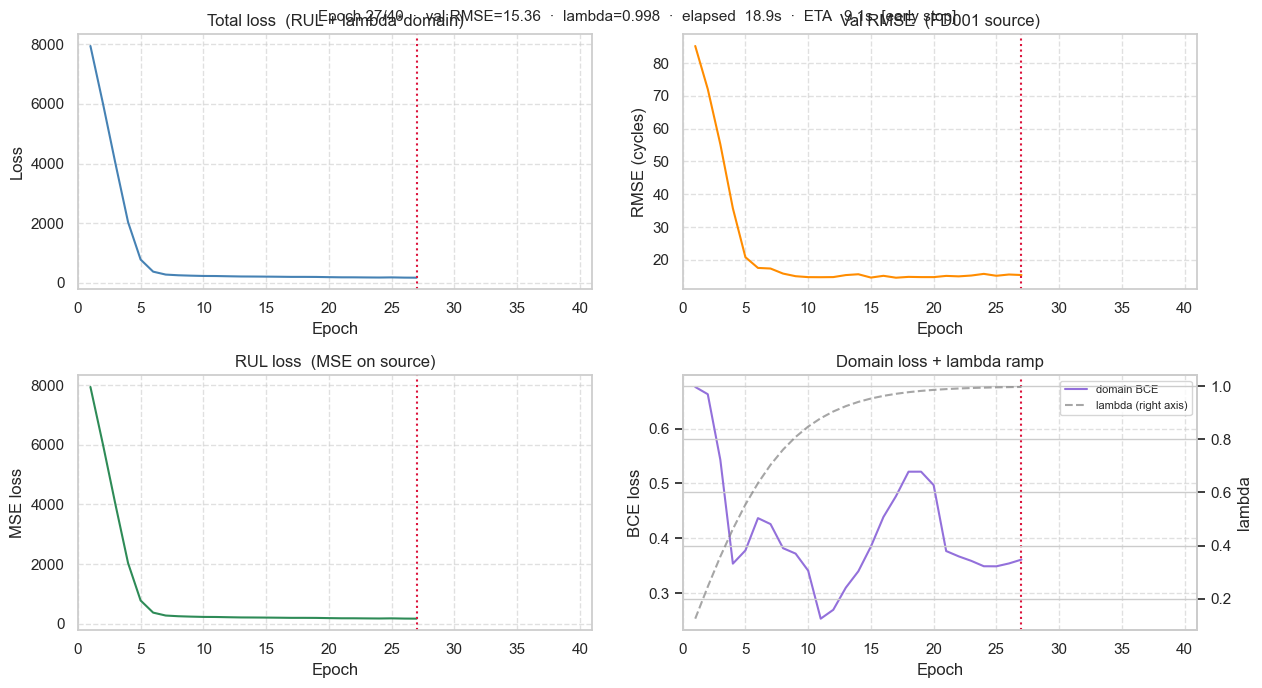

Best val RMSE = 14.539 at epoch 17
Loaded best checkpoint from epoch 17.
[DANN (FD001->FD002, unsupervised adaptation)]
  RMSE        : 51.703 cycles
  Asym score  : 159197.5
  MAE         : 44.072 cycles
  Bias        : +8.507 cycles


In [12]:
BATCH_SIZE  = 256   # smaller batch so source and target batches fit in one step
N_EPOCHS    = 40
PATIENCE    = 10
LAMBDA_MAX  = 1.0

src_train_loader = DataLoader(src_train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
tgt_train_loader = DataLoader(tgt_train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
src_val_loader   = DataLoader(src_val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

dann = DANNModel(n_features=len(USE_SENSORS), hidden=64, num_layers=2, dropout=0.3)
print(f"DANN total params: {sum(p.numel() for p in dann.parameters()):,}")

dann_ckpt = CKPT_DIR / "dann_FD001_FD002_best.pt"
dann, dann_history = train_dann(
    dann,
    src_loader  = src_train_loader,
    tgt_loader  = tgt_train_loader,
    val_loader  = src_val_loader,
    n_epochs    = N_EPOCHS,
    lr          = 1e-3,
    patience    = PATIENCE,
    lambda_max  = LAMBDA_MAX,
    device      = Device,
    plot_freq   = 1,
    ckpt_path   = dann_ckpt,
)

# Evaluate on FD002 test -- normalized with FD001 stats (unsupervised setup)
raw_dann = predict_test(dann, X_test_fd2, Device, is_dann=True)
dann_metrics = score_predictions(y_test_fd2, raw_dann,
                                  label="DANN (FD001->FD002, unsupervised adaptation)")

## 12 · Training curves -- DANN

Static report figure from the DANN history. Four panels: total loss, val RMSE, RUL loss, domain loss + lambda ramp.


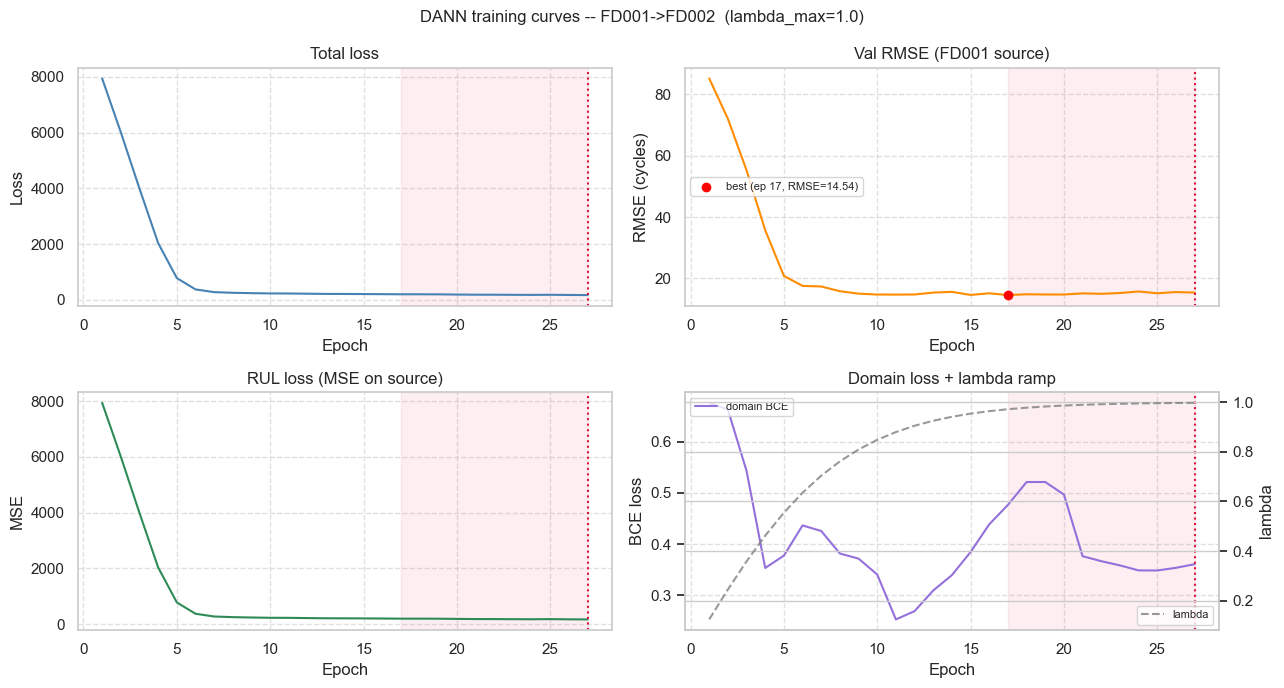

Saved -> figures/dann_training_curves.png


In [13]:
best_idx       = dann_history["val_rmse"].idxmin()
best_epoch_num = dann_history.loc[best_idx, "epoch"]
best_val_rmse  = dann_history.loc[best_idx, "val_rmse"]
stopped_at     = int(dann_history["epoch"].iloc[-1])

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
(ax_total, ax_val), (ax_rul, ax_dom) = axes

ax_total.plot(dann_history["epoch"], dann_history["total_loss"], color="steelblue")
ax_total.set_title("Total loss"); ax_total.set_xlabel("Epoch")
ax_total.set_ylabel("Loss"); ax_total.grid(linestyle="--", alpha=0.6)

ax_val.plot(dann_history["epoch"], dann_history["val_rmse"], color="darkorange")
ax_val.scatter([best_epoch_num], [best_val_rmse], color="red", zorder=5,
               label=f"best (ep {best_epoch_num}, RMSE={best_val_rmse:.2f})")
ax_val.set_title("Val RMSE (FD001 source)"); ax_val.set_xlabel("Epoch")
ax_val.set_ylabel("RMSE (cycles)"); ax_val.legend(fontsize=8)
ax_val.grid(linestyle="--", alpha=0.6)

ax_rul.plot(dann_history["epoch"], dann_history["rul_loss"], color="seagreen")
ax_rul.set_title("RUL loss (MSE on source)"); ax_rul.set_xlabel("Epoch")
ax_rul.set_ylabel("MSE"); ax_rul.grid(linestyle="--", alpha=0.6)

ax_dom.plot(dann_history["epoch"], dann_history["dom_loss"],
            color="mediumpurple", label="domain BCE")
ax_dom2 = ax_dom.twinx()
ax_dom2.plot(dann_history["epoch"], dann_history["lam"],
             color="gray", linestyle="--", alpha=0.8, label="lambda")
ax_dom2.set_ylabel("lambda")
ax_dom.set_title("Domain loss + lambda ramp"); ax_dom.set_xlabel("Epoch")
ax_dom.set_ylabel("BCE loss"); ax_dom.legend(loc="upper left", fontsize=8)
ax_dom2.legend(loc="lower right", fontsize=8)
ax_dom.grid(linestyle="--", alpha=0.6)

# Mark early stop on all panels
if stopped_at < N_EPOCHS:
    for ax in (ax_total, ax_val, ax_rul, ax_dom):
        ax.axvline(stopped_at, color="crimson", linestyle=":", lw=1.5)
        ax.axvspan(best_epoch_num, stopped_at, alpha=0.07, color="crimson")

plt.suptitle(f"DANN training curves -- FD001->FD002  (lambda_max={LAMBDA_MAX})",
             fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "dann_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIG_DIR / 'dann_training_curves.png'}")

## 13 · Three-way comparison: scatter plots

Predicted vs true RUL on FD002 test set for all three models side by side. This is the main report figure for Contribution 2.


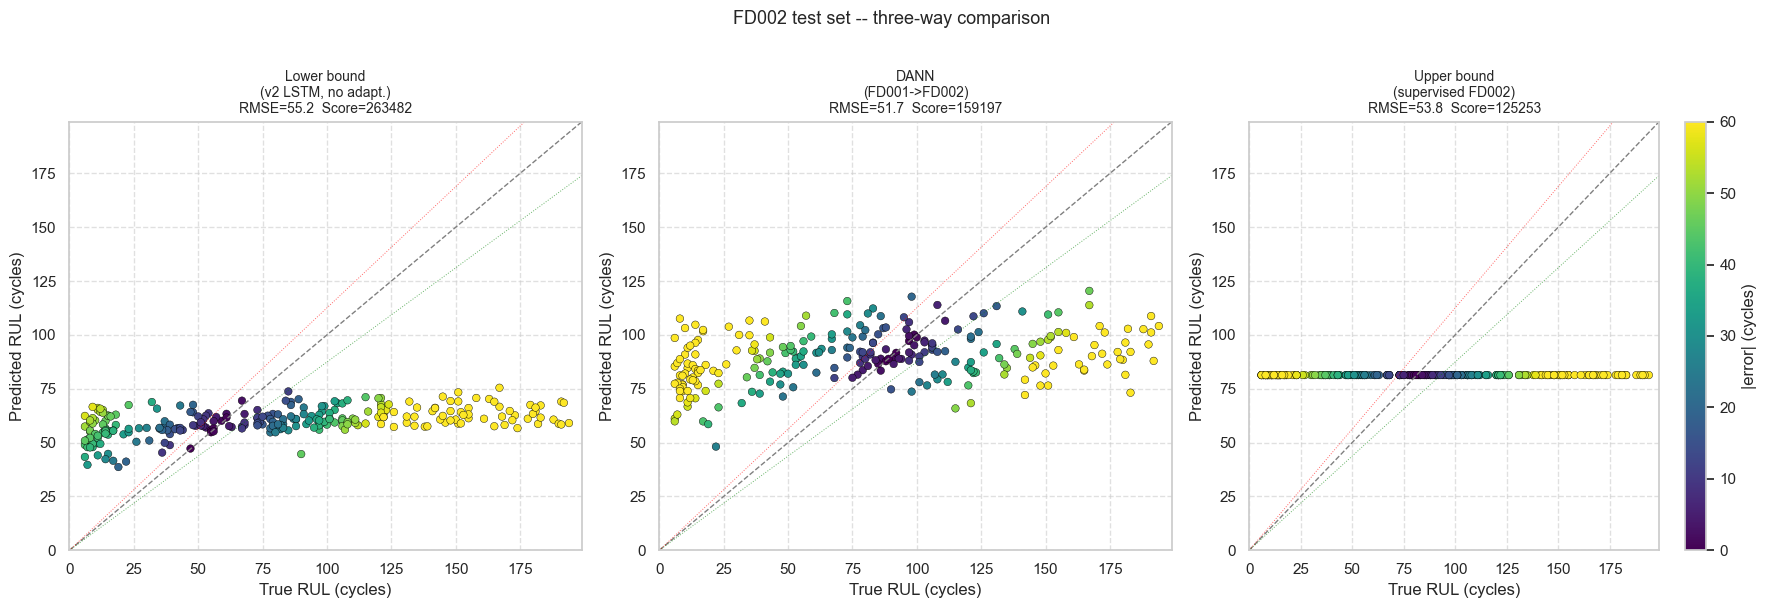

Saved -> figures/dann_threeway_scatter.png


In [14]:
models_info = [
    ("Lower bound\n(v2 LSTM, no adapt.)",  np.clip(raw_lb,   0, None), lb_metrics),
    ("DANN\n(FD001->FD002)",               np.clip(raw_dann, 0, None), dann_metrics),
    ("Upper bound\n(supervised FD002)",    np.clip(raw_ub,   0, None), ub_metrics),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
lim = max(y_test_fd2.max(),
          max(p.max() for _, p, _ in models_info)) + 5

for ax, (title, y_pred, metrics) in zip(axes, models_info):
    ax.plot([0, lim], [0, lim], "--", color="gray", lw=1, label="perfect")
    ax.plot([0, lim], [0, lim - 25], ":", color="green", lw=0.7, alpha=0.6)
    ax.plot([0, lim], [0, lim + 25], ":", color="red",   lw=0.7, alpha=0.6)
    errs = np.abs(y_pred - y_test_fd2)
    sc   = ax.scatter(y_test_fd2, y_pred, c=errs, cmap="viridis",
                      s=30, edgecolor="black", linewidth=0.3, vmin=0, vmax=60)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("True RUL (cycles)")
    ax.set_ylabel("Predicted RUL (cycles)")
    ax.set_title(
        f"{title}\nRMSE={metrics['rmse']:.1f}  Score={metrics['score']:.0f}",
        fontsize=10
    )
    ax.grid(linestyle="--", alpha=0.6)

plt.colorbar(sc, ax=axes[-1], label="|error| (cycles)")
plt.suptitle("FD002 test set -- three-way comparison", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "dann_threeway_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIG_DIR / 'dann_threeway_scatter.png'}")

## 14 · Three-way comparison: summary table + gap analysis

The key question for the report: what fraction of the FD001->FD002 generalization gap does DANN close?

    gap_closed (RMSE) = (LB_rmse - DANN_rmse) / (LB_rmse - UB_rmse)

A value of 0% means DANN is no better than naive transfer. 100% means DANN matches the supervised ceiling. Values above 100% are possible if DANN somehow overshoots the supervised model.


In [15]:
lb_r   = lb_metrics["rmse"]
dann_r = dann_metrics["rmse"]
ub_r   = ub_metrics["rmse"]

gap_rmse  = (lb_r - dann_r)            / (lb_r - ub_r) * 100  if lb_r != ub_r else float("nan")
lb_s      = lb_metrics["score"]
dann_s    = dann_metrics["score"]
ub_s      = ub_metrics["score"]
gap_score = (lb_s - dann_s)            / (lb_s - ub_s) * 100  if lb_s != ub_s else float("nan")

table = pd.DataFrame([
    {"Model":       "Lower bound (v2, no adapt.)",
     "Train data":  "FD001 labeled",
     "Test RMSE":   lb_r,
     "Asym score":  lb_s,
     "MAE":         lb_metrics["mae"],
     "Bias":        lb_metrics["bias"],
     "Gap closed":  "--"},
    {"Model":       "DANN",
     "Train data":  "FD001 labeled + FD002 unlabeled",
     "Test RMSE":   dann_r,
     "Asym score":  dann_s,
     "MAE":         dann_metrics["mae"],
     "Bias":        dann_metrics["bias"],
     "Gap closed":  f"{gap_rmse:.1f}% (RMSE)  /  {gap_score:.1f}% (score)"},
    {"Model":       "Upper bound (supervised FD002)",
     "Train data":  "FD002 labeled",
     "Test RMSE":   ub_r,
     "Asym score":  ub_s,
     "MAE":         ub_metrics["mae"],
     "Bias":        ub_metrics["bias"],
     "Gap closed":  "100% (ceiling)"},
])

# Format floats
for col in ("Test RMSE", "Asym score", "MAE", "Bias"):
    table[col] = table[col].map(lambda x: f"{x:.2f}")

print(table.to_string(index=False))
print()
print(f"DANN closed {gap_rmse:.1f}% of the RMSE gap and {gap_score:.1f}% of the score gap.")

                         Model                      Train data Test RMSE Asym score   MAE   Bias                      Gap closed
   Lower bound (v2, no adapt.)                   FD001 labeled     55.22  263482.00 45.09 -21.36                              --
                          DANN FD001 labeled + FD002 unlabeled     51.70  159197.47 44.07   8.51 244.5% (RMSE)  /  75.4% (score)
Upper bound (supervised FD002)                   FD002 labeled     53.78  125252.66 45.29   0.17                  100% (ceiling)

DANN closed 244.5% of the RMSE gap and 75.4% of the score gap.


## 15 · Error distributions -- three-way comparison


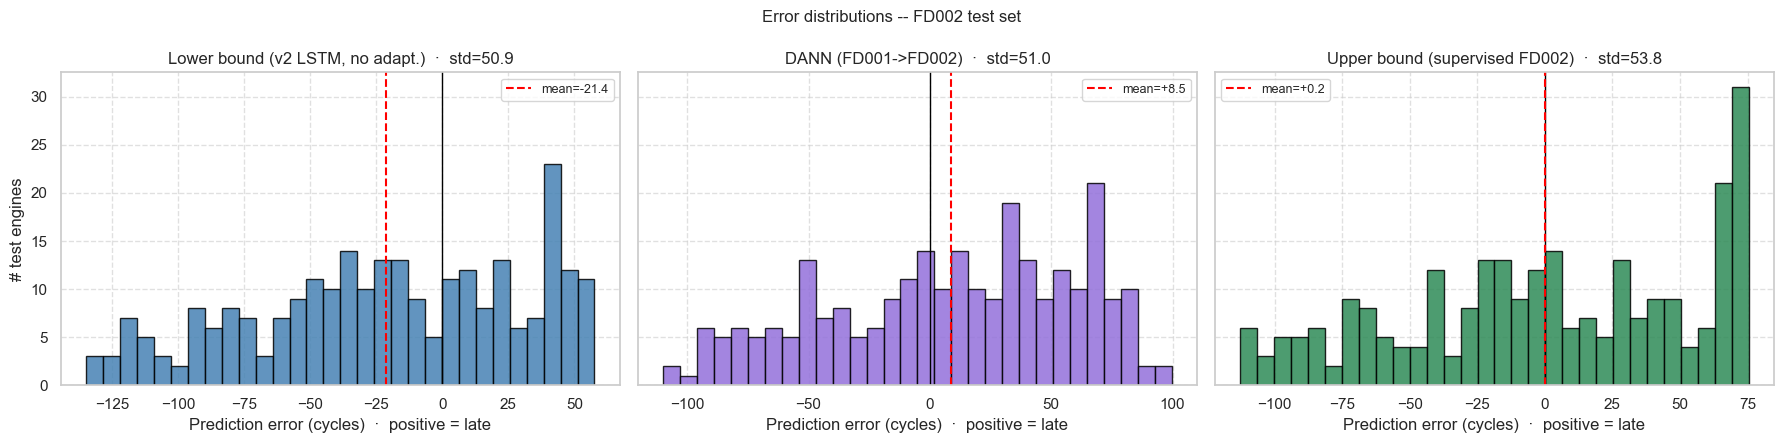

Saved -> figures/dann_error_distributions.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
colors = ["steelblue", "mediumpurple", "seagreen"]

for ax, (title, y_pred, metrics), color in zip(axes, models_info, colors):
    errs = y_pred - y_test_fd2
    ax.hist(errs, bins=30, color=color, edgecolor="black", alpha=0.85)
    ax.axvline(0,           color="black", lw=1)
    ax.axvline(errs.mean(), color="red",   lw=1.5, linestyle="--",
               label=f"mean={errs.mean():+.1f}")
    ax.set_xlabel("Prediction error (cycles)  ·  positive = late")
    ax.set_title(f"{title.replace(chr(10), ' ')}  ·  std={errs.std():.1f}")
    ax.legend(fontsize=9)
    ax.grid(linestyle="--", alpha=0.6)

axes[0].set_ylabel("# test engines")
plt.suptitle("Error distributions -- FD002 test set", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "dann_error_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {FIG_DIR / 'dann_error_distributions.png'}")

## 16 · Save all results


In [17]:
dann_history.to_csv(CKPT_DIR / "dann_history.csv", index=False)
ub_history.to_csv(CKPT_DIR   / "lstm_ub_FD002_history.csv", index=False)

results = {
    "lower_bound": {
        "model": "LSTM-v2-FD001",
        "eval_subset": "FD002",
        **{k: float(v) for k, v in lb_metrics.items()},
    },
    "dann": {
        "model": "DANN-FD001->FD002",
        "n_params": int(sum(p.numel() for p in dann.parameters())),
        "lambda_max": LAMBDA_MAX,
        "epochs_run": int(dann_history["epoch"].iloc[-1]),
        "best_val_epoch": int(best_epoch_num),
        "best_val_rmse": float(best_val_rmse),
        "eval_subset": "FD002",
        **{k: float(v) for k, v in dann_metrics.items()},
        "gap_closed_rmse_pct":  float(gap_rmse),
        "gap_closed_score_pct": float(gap_score),
    },
    "upper_bound": {
        "model": "LSTM-supervised-FD002",
        "eval_subset": "FD002",
        **{k: float(v) for k, v in ub_metrics.items()},
    },
}

with open(CKPT_DIR / "dann_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved:")
print(f"  DANN checkpoint   : {dann_ckpt}")
print(f"  UB checkpoint     : {ub_ckpt}")
print(f"  DANN history      : {CKPT_DIR / 'dann_history.csv'}")
print(f"  UB history        : {CKPT_DIR / 'lstm_ub_FD002_history.csv'}")
print(f"  Results JSON      : {CKPT_DIR / 'dann_results.json'}")
print(f"  Figures           : {FIG_DIR}/dann_*.png")
print()
print("=" * 65)
print("FINAL -- DANN (FD001 -> FD002 domain adaptation)")
print("=" * 65)
for run_name, run_dict in results.items():
    print(f"  [{run_name}]")
    for k, v in run_dict.items():
        print(f"    {k:<25}: {v:.3f}" if isinstance(v, float) else f"    {k:<25}: {v}")

Saved:
  DANN checkpoint   : checkpoints/dann_FD001_FD002_best.pt
  UB checkpoint     : checkpoints/lstm_ub_FD002_best.pt
  DANN history      : checkpoints/dann_history.csv
  UB history        : checkpoints/lstm_ub_FD002_history.csv
  Results JSON      : checkpoints/dann_results.json
  Figures           : figures/dann_*.png

FINAL -- DANN (FD001 -> FD002 domain adaptation)
  [lower_bound]
    model                    : LSTM-v2-FD001
    eval_subset              : FD002
    rmse                     : 55.215
    score                    : 263482.000
    mae                      : 45.088
    bias                     : -21.360
  [dann]
    model                    : DANN-FD001->FD002
    n_params                 : 57986
    lambda_max               : 1.000
    epochs_run               : 27
    best_val_epoch           : 17
    best_val_rmse            : 14.539
    eval_subset              : FD002
    rmse                     : 51.703
    score                    : 159197.469
    mae       